In [50]:
import os
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import shutil
import pandas as pd
from source import image_id_converter as img_idc
#from source import sort_img_files as sif
from source import detect_persons_yolo as dpy
from source import llm_input as llm_i
from source import llm_output as llm_o
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import ollama
import json
import re
import pickle

In [3]:
os.getcwd()

'/storage/homefs/sh98e089'

In [4]:
# !rm yolov8n.pt

In [5]:
def store_duration(time_analysis_dict, time_analysis_for_df_dict, analysis_name, duration,
                  timestamp_start_is_photo_analysis,
                  timestamp_end_is_photo_analysis):
    time_analysis_dict[analysis_name] = {}
    time_analysis_dict[analysis_name]['duration_str'] = f"Analysis took: {duration}"
    time_analysis_dict[analysis_name]['duration_seconds'] = total_seconds
    time_analysis_dict[analysis_name]['duration_seconds_str'] = f"Analysis took: {total_seconds:.2f} seconds"
    time_analysis_dict[analysis_name]['duration_minutes'] = total_seconds/60
    time_analysis_dict[analysis_name]['duration_minutes_str'] = f"Analysis took: {total_seconds/60:.2f} minutes"
    time_analysis_dict[analysis_name]['time_stamp_start'] = timestamp_start_is_photo_analysis
    time_analysis_dict[analysis_name]['time_stamp_end'] = timestamp_end_is_photo_analysis

    time_analysis_for_df_dict['analysis_name'].append(analysis_name)
    time_analysis_for_df_dict['time_stamp_start'].append(timestamp_start_is_photo_analysis)
    time_analysis_for_df_dict['duration_str'].append(f"Analysis took: {duration}")
    time_analysis_for_df_dict['duration_seconds'].append(total_seconds)
    time_analysis_for_df_dict['duration_seconds_str'].append(f"Analysis took: {total_seconds:.2f} seconds")
    time_analysis_for_df_dict['duration_minutes'].append(total_seconds/60)
    time_analysis_for_df_dict['duration_minutes_str'].append(f"Analysis took: {total_seconds/60:.2f} minutes")

    return time_analysis_dict, time_analysis_for_df_dict
    

## Set paths:

In [6]:
#root_path = Path('/Users/stephanehess/Documents/CAS_AML/dias_digit_project/project')

In [7]:
#project_path = Path(os.getcwd())
#root_path = project_path / '..' / 'test_data_folders/test_filter_out_people_multi_approach'
# root_path = project_path

project_path = Path(os.getcwd())
root_path = project_path / 'test_filter_out_people_multi_approach'
# root_path = project_path

In [8]:
# project_path = Path(os.getcwd())
# root_path = project_path
# Define paths
# image_dir = root_path/"../data"  # Replace with your directory containing images
# Adaptation to the different file structure on ubelix: 
data_path = root_path/"data"  # Replace with your directory containing images
tif_data_path = root_path / 'data_1'
jpg_data_path = root_path / 'data_jpg'
image_dir = jpg_data_path


In [9]:
data_path

PosixPath('/storage/homefs/sh98e089/test_filter_out_people_multi_approach/data')

### Load label data:

In [10]:
label_data = pd.read_csv(data_path/'labels_mod.csv')
label_data.head()

,image_id,with_person,person_recognisable,is_photo,with_church,in_high_alpine_environment
0,id001,1,1,1,0,0
1,id002,0,0,1,1,0
2,id003,0,0,1,0,0
3,id004,0,0,1,0,0
4,id005,0,0,1,0,0


In [11]:
# Reconvert image ids to integers (e.g. '234') as strings from the form they were saved in (e.g. 'id234' 
# to ensure string data type to deal with duck typing): 
img_ids = list(label_data.image_id)
label_data['image_id'] = img_idc.reconvert_image_ids(img_ids)
label_data.head()

,image_id,with_person,person_recognisable,is_photo,with_church,in_high_alpine_environment
0,001,1,1,1,0,0
1,002,0,0,1,1,0
2,003,0,0,1,0,0
3,004,0,0,1,0,0
4,005,0,0,1,0,0


### The following cell is only required for the test run on the test data: 

In [12]:
# Select only rows referring to images in the smaller data set (test run):

# Make sure no .DS_Store file is included in jpg_data_path: 
import os
ds_file_path = jpg_data_path / '.DS_Store'

# Remove a specific .DS_Store file
if os.path.exists(ds_file_path):
    os.remove(ds_file_path)
    print("Removed .DS_Store")
else:
    print(".DS_Store not found")

# Find all .ipynb_checkpoints directories
for checkpoint_dir in jpg_data_path.rglob('.ipynb_checkpoints'):
    if checkpoint_dir.is_dir():
        print(f"Removing: {checkpoint_dir}")
        shutil.rmtree(checkpoint_dir)



# Get list of image files present:
image_files = os.listdir(jpg_data_path)

#image_files.remove(".ipynb_checkpoints")



# Extract image ids from image file names:
img_ids = [image_file.split('Oberland')[1].split('.')[0] for image_file in image_files]
img_ids.sort()
print(img_ids)

# Select relevant rows from label_data data frame by id list: 
select_bools = [img_id in img_ids for img_id in label_data.image_id]

label_data = label_data[select_bools].copy()
label_data

.DS_Store not found
['002', '003', '008', '015', '022', '023', '033', '035', '043', '081', '082', '107']


,image_id,with_person,person_recognisable,is_photo,with_church,in_high_alpine_environment
1,002,0,0,1,1,0
2,003,0,0,1,0,0
7,008,0,0,1,1,0
14,015,1,1,1,0,0
21,022,0,0,0,0,0
22,023,1,1,1,0,0
32,033,0,0,0,0,0
34,035,0,0,1,1,0
42,043,0,0,1,1,0
80,081,0,0,0,0,0


### Convert tif images to jpg images:

In [13]:
source_folder = tif_data_path
destination_folder = jpg_data_path

llm_i.convert_tif_to_jpg(source_folder, destination_folder, quality=100)


Error converting BernerOberland002.tif: cannot identify image file '/storage/homefs/sh98e089/test_filter_out_people_multi_approach/data_1/BernerOberland002.tif'
Error converting BernerOberland023.tif: cannot identify image file '/storage/homefs/sh98e089/test_filter_out_people_multi_approach/data_1/BernerOberland023.tif'
Converted: BernerOberland081.tif -> BernerOberland081.jpg
Converted: BernerOberland033.tif -> BernerOberland033.jpg
Converted: BernerOberland043.tif -> BernerOberland043.jpg
Error converting BernerOberland008.tif: cannot identify image file '/storage/homefs/sh98e089/test_filter_out_people_multi_approach/data_1/BernerOberland008.tif'
Error converting BernerOberland107.tif: cannot identify image file '/storage/homefs/sh98e089/test_filter_out_people_multi_approach/data_1/BernerOberland107.tif'
Converted: BernerOberland082.tif -> BernerOberland082.jpg
Error converting BernerOberland035.tif: cannot identify image file '/storage/homefs/sh98e089/test_filter_out_people_multi_ap

['BernerOberland081.jpg',
 'BernerOberland033.jpg',
 'BernerOberland043.jpg',
 'BernerOberland082.jpg',
 'BernerOberland015.jpg',
 'BernerOberland022.jpg']

## Yolo:

### Define the pretrained model:

In [14]:
# Load the YOLO model
model = YOLO("yolov8n.pt")  # Use yolov8n (nano) for faster inference


In [15]:
# Save information about model version being used: 
model_name = model.model_name
model_name_file_path = data_path /'yolo_model_info.txt'
model_name_file_path
with open(model_name_file_path, 'w') as f:
    f.write(f"YOLO Model: {model_name}")

### Prepare data objects:

In [16]:
# Prepare empty data frame to store performance metrics:
ml_metrics_yolo = pd.DataFrame({})

In [17]:
time_analyses = {}
time_analyses_yolo = {}
time_analyses_yolo['analysis_name'] = []
time_analyses_yolo['time_stamp_start'] = []
time_analyses_yolo['duration_str'] = []
time_analyses_yolo['duration_seconds'] = []
time_analyses_yolo['duration_seconds_str'] = []
time_analyses_yolo['duration_minutes'] = []
time_analyses_yolo['duration_minutes_str'] = []

timestamp_start_workflow = pd.Timestamp.now()
timestamp_start_workflow

Timestamp('2026-02-21 16:25:27.797609')

### Set parameters: 

In [18]:
analysis_name = 'pers_yolo'
label_name = 'with_person'
prediction_name = 'with_person_pred'

## Detect persons with pretrained yolo:

In [19]:
# img_ids, with_person = sif.sort_img_files(image_dir, model, output_dir_with_person, 
#                                           output_dir_without_person, threshold=0.25)


timestamp_start_pers_yolo = pd.Timestamp.now()

img_ids, with_person = dpy.detect_persons_yolo(image_dir, model, threshold=0.25,
                                              file_format="jpg")
timestamp_end_pers_yolo = pd.Timestamp.now()


duration = timestamp_end_pers_yolo - timestamp_start_pers_yolo

total_seconds = duration.total_seconds()
print(total_seconds)

# Store information about duration: 
time_analyses, time_analyses_yolo = store_duration(time_analyses, time_analyses_yolo, analysis_name, 
               duration, timestamp_start_pers_yolo,
              timestamp_end_pers_yolo)

yolo_timestamp_id = timestamp_start_pers_yolo.strftime('%Y%m%d_%H%M%S')


Filtering complete!
2.607774


In [20]:
print(img_ids)

['008', '015', '081', '035', '033', '003', '043', '022', '082', '107', '023', '002']


In [21]:
print(with_person)

[False, True, False, True, False, False, False, False, False, False, True, True]


In [22]:
print(len(img_ids))
print(len(with_person))

12
12


## Load label data and merge with prediction data:

In [23]:
# Load person predictions into a dataframe: 
results_person = pd.DataFrame({'image_id': img_ids, label_name: with_person})
# Add one-hot-coded person predictions:
results_person[prediction_name]= [1 if x else 0 for x in results_person.with_person]
results_person_select = results_person.loc[:, ['image_id', prediction_name]]
# Take copy of label_data and select relevant columns:
with_without_person = label_data.copy()
with_without_person = with_without_person.iloc[:, 0:3]
# Merge label data with the predictions:
labels_results_yolo = with_without_person.merge(results_person_select, how='inner', on='image_id')
labels_results_yolo.head()

,image_id,with_person,person_recognisable,with_person_pred
0,002,0,0,1
1,003,0,0,0
2,008,0,0,0
3,015,1,1,1
4,022,0,0,0


### Calculate performance metrics:

In [24]:
# Calculate sensitivity and specificity for person predictions and get the different data subsets based on label and predictions:
subsets_and_metrics = llm_o.get_classification_subsets_metrics(labels_results_yolo, label_name, 
                                                               prediction_name)
positives, negatives, true_positives, true_negatives, false_negatives, false_positives, sensitivity, specificity = subsets_and_metrics 
print(sensitivity)
print(specificity)


1.0
0.8


### Inspect false negatives:

In [25]:
false_negatives

,image_id,with_person,person_recognisable,with_person_pred


### Inspect false positives:

In [26]:
false_positives

,image_id,with_person,person_recognisable,with_person_pred
0,002,0,0,1
7,035,0,0,1


### Add performance metrics to data frame: 

In [27]:
# Get number of positives, negatives, true and false: 
number_positives = positives.shape[0]
number_negatives = negatives.shape[0]
number_true_positives = true_positives.shape[0]
number_false_positives = false_positives.shape[0]
number_true_negatives = true_negatives.shape[0]
number_false_negatives = false_negatives.shape[0]

# Put everything into a dataframe: 
ml_metrics_to_stack = pd.DataFrame({})
ml_metrics_to_stack['analysis_name'] = [analysis_name]
ml_metrics_to_stack['time_stamp'] = [timestamp_start_pers_yolo]
ml_metrics_to_stack['positives'] = [number_positives]
ml_metrics_to_stack['negatives'] = [number_negatives]
ml_metrics_to_stack['true_positives'] = [number_true_positives]
ml_metrics_to_stack['false_positives'] = [number_false_positives]
ml_metrics_to_stack['true_negatives'] = [number_true_negatives]
ml_metrics_to_stack['false_negatives'] = [number_false_negatives]
ml_metrics_to_stack['sensitivity'] = [sensitivity]
ml_metrics_to_stack['specificity'] = [specificity]

ml_metrics_to_concat = [ml_metrics_yolo, ml_metrics_to_stack]
ml_metrics_yolo = pd.concat(ml_metrics_to_concat)
ml_metrics_yolo

,analysis_name,time_stamp,positives,negatives,true_positives,false_positives,true_negatives,false_negatives,sensitivity,specificity
0,pers_yolo,2026-02-21 16:25:27.811412,2,10,2,2,8,0,1.0,0.8


### Plot confusion matrix:

Confusion Matrix:


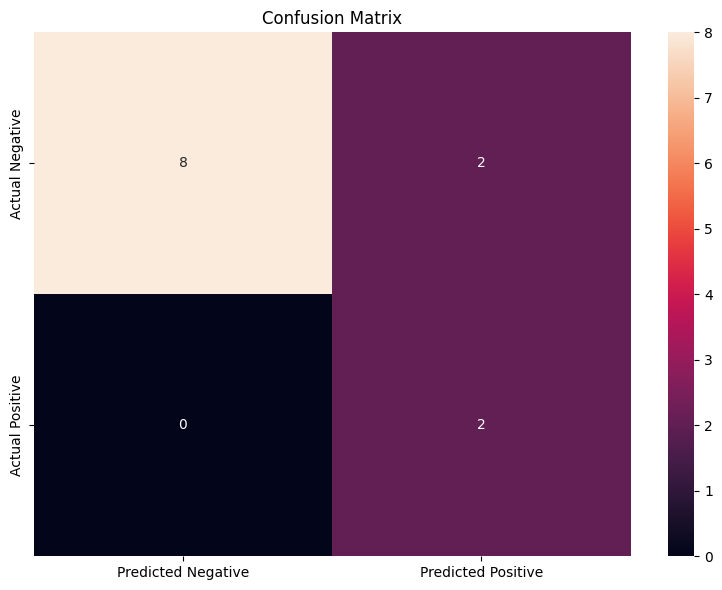

True Positives: 2
False Positives: 2
True Negatives: 8
False Negatives: 0

Sensitivity (Recall): 1.0000
Specificity: 0.8000
Precision: 0.5000
Miss Rate (False Negative Rate): 0.0000
F1 Score: 0.6667


In [28]:

cases = true_positives, false_positives, true_negatives, false_negatives, positives, negatives

# llm_o.plot_conf_matrix(labels_results, 'with_person', 'with_person_yolo_pred', cases)
fig = llm_o.save_conf_matrix(labels_results_yolo, label_name, prediction_name, cases)


### Save confusion matrix as pdf:

In [29]:
# The fig object was created when plotting the confusion matrix
# so now we can use it to save the plot as pdf:
file_name = 'conf_matrix_metrics_' + analysis_name + '.pdf'
conf_matrix_path = data_path / file_name
fig.savefig(conf_matrix_path)
plt.close(fig)


### Recalculate performance metrics with recognisable_label as ground truth (instead of person_label):

In [30]:
analysis_name = 'pers_recognisable_yolo'
label_name = 'person_recognisable'
prediction_name = 'with_person_pred'

In [31]:
analysis_name = 'pers_recognisable_yolo'
label_name = 'person_recognisable'
prediction_name = 'with_person_pred'

# Calculate sensitivity and specificity for person predictions and get the different data subsets based on label and predictions:
subsets_and_metrics = llm_o.get_classification_subsets_metrics(labels_results_yolo, label_name, 
                                                               prediction_name)

(positives, negatives, true_positives, true_negatives, false_negatives, 
 false_positives, sensitivity, specificity) = subsets_and_metrics
print(sensitivity) 
print(specificity)


1.0
0.8


### Add performance metrics to data frame: 

In [32]:
# Get number of positives and negatives, true and false: 
number_positives = positives.shape[0]
number_negatives = negatives.shape[0]
number_true_positives = true_positives.shape[0]
number_false_positives = false_positives.shape[0]
number_true_negatives = true_negatives.shape[0]
number_false_negatives = false_negatives.shape[0]

# Put everything into a dataframe:
ml_metrics_to_stack = pd.DataFrame({})
ml_metrics_to_stack['analysis_name'] = [analysis_name]
ml_metrics_to_stack['time_stamp'] = [timestamp_start_pers_yolo]
ml_metrics_to_stack['positives'] = [number_positives]
ml_metrics_to_stack['negatives'] = [number_negatives]
ml_metrics_to_stack['true_positives'] = [number_true_positives]
ml_metrics_to_stack['false_positives'] = [number_false_positives]
ml_metrics_to_stack['true_negatives'] = [number_true_negatives]
ml_metrics_to_stack['false_negatives'] = [number_false_negatives]
ml_metrics_to_stack['sensitivity'] = [sensitivity]
ml_metrics_to_stack['specificity'] = [specificity]

ml_metrics_to_concat = [ml_metrics_yolo, ml_metrics_to_stack]
ml_metrics_yolo = pd.concat(ml_metrics_to_concat)
ml_metrics_yolo

,analysis_name,time_stamp,positives,negatives,true_positives,false_positives,true_negatives,false_negatives,sensitivity,specificity
0,pers_yolo,2026-02-21 16:25:27.811412,2,10,2,2,8,0,1.0,0.8
0,pers_recognisable_yolo,2026-02-21 16:25:27.811412,2,10,2,2,8,0,1.0,0.8


### Plot confusion matrix:

Confusion Matrix:


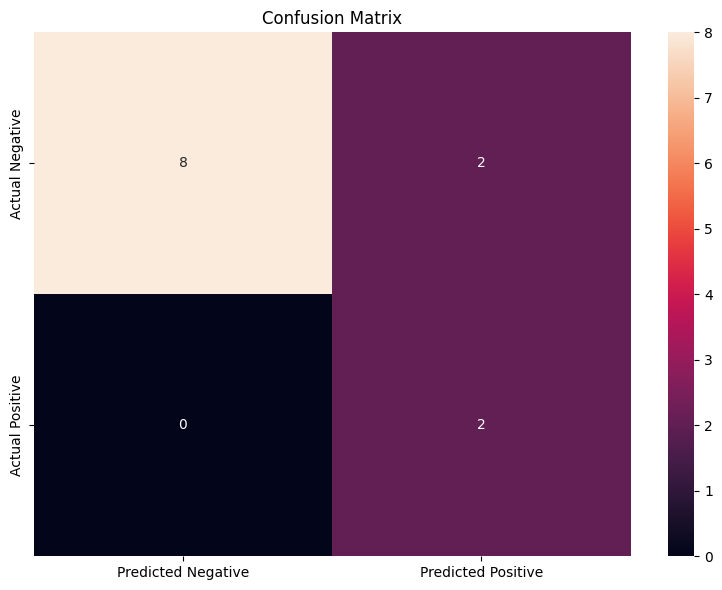

True Positives: 2
False Positives: 2
True Negatives: 8
False Negatives: 0

Sensitivity (Recall): 1.0000
Specificity: 0.8000
Precision: 0.5000
Miss Rate (False Negative Rate): 0.0000
F1 Score: 0.6667


In [33]:
cases = true_positives, false_positives, true_negatives, false_negatives, positives, negatives

#llm_o.plot_conf_matrix(labels_results, 'person_recognisable', 'with_person_yolo_pred', cases)
fig = llm_o.save_conf_matrix(labels_results_yolo, label_name, prediction_name, cases)


### Save confusion matrix as pdf:

In [34]:

# The fig object was created when plotting the confusion matrix
# so now we can use it to save the plot as pdf:
file_name = 'conf_matrix_metrics_' + analysis_name + '.pdf'
conf_matrix_path = data_path / file_name
fig.savefig(conf_matrix_path)
plt.close(fig)


In [35]:
labels_results_yolo

,image_id,with_person,person_recognisable,with_person_pred
0,002,0,0,1
1,003,0,0,0
2,008,0,0,0
3,015,1,1,1
4,022,0,0,0
5,023,1,1,1
6,033,0,0,0
7,035,0,0,1
8,043,0,0,0
9,081,0,0,0


## Save labels results: 

In [36]:
workflow_name = 'people_detect_multi_approach_'

In [37]:
filename = workflow_name + 'labels_results_yolo_' + yolo_timestamp_id + '.csv'
labels_results_yolo.to_csv(data_path/filename)

### Save ml metrics: 

In [38]:
filename = workflow_name + 'ml_metrics_yolo_' + yolo_timestamp_id + '.csv'
ml_metrics_yolo.to_csv(data_path/filename)


### Save time analysis:

In [39]:

# Define file name: 

time_analyses_yolo_file_name = 'times_' + workflow_name + 'yolo_' + yolo_timestamp_id + '.pkl'

# Save dictionary:
time_analyses_yolo_output_path = os.path.join(data_path, time_analyses_yolo_file_name)
with open(time_analyses_yolo_output_path, 'wb') as f:
   pickle.dump(time_analyses_yolo, f)

# Reload saved dictionary to check if saving worked:
with open(time_analyses_yolo_output_path, 'rb') as f:
   reloaded_time_analyses_yolo = pickle.load(f)

# Check if original and reloaded dictionary are the same:
print(len(time_analyses_yolo))
print(type(time_analyses_yolo))
print(type(reloaded_time_analyses_yolo))
print(len(reloaded_time_analyses_yolo))

print(time_analyses_yolo.keys() == reloaded_time_analyses_yolo.keys())


7
<class 'dict'>
<class 'dict'>
7
True


## LLM

In [40]:
def create_analysis_prompt_person():
    """Create the structured prompt for image analysis."""
    return """
    Analyze this image and return ONLY a Python dictionary in exactly this format:
    
    {
        'contains_persons': X,  # True if the image contains a person or multiple persons, False if the image does not contain any person.
        'additional_comments': '' # Any additional observations or empty string if none.
    }
    
    Replace X with True (image contains one or multiple persons) or False (does not contain any person).
    Return ONLY the dictionary, no other text.
    Your answer MUST have the exact structue of the dictionary described above (all keys MUST be present). 
    If you cannot answer the question in the way implied by this structure, enter 'None' as value and offer 
    your answer and explanations under 'additional_comments'.
    """

In [41]:
def analyse_giub_img_dir_llm(jpg_data_path, create_analysis_prompt, model_function):
    # Get time stamp:
    timestamp_start_is_photo_analysis = pd.Timestamp.now()
    
    # Get list of image files to analyse: 
    image_files = os.listdir(jpg_data_path)
    print(image_files)
    img_ids = [image_file.split('Oberland')[1].split('.')[0] for image_file in image_files]
    
    # Make empty dictionary to store results:
    image_descr = {}
    
    # Loop through images to get answers: 
    for image_file in image_files:
        image_path = jpg_data_path / image_file
        path_str = str(image_path)
        print('\n')
        print(path_str)
        parts = path_str.split('.jpg')
        img_id = parts[-2][-3:]
    
        # Analyse image, get values for each of the categorical variables specified above:
        #image_description = analyze_image_structured(image_path)
        #image_description = llm_o.analyze_image_structured(image_path, create_analysis_prompt)
        image_description = llm_o.analyze_image_structured(image_path, create_analysis_prompt, model_function)
        print(image_description)
        
        dict_type_bool = type(image_description) == dict
            
        #print(image_description)
        image_descr[img_id] = image_description
    
    timestamp_end_is_photo_analysis = pd.Timestamp.now()

    return timestamp_start_is_photo_analysis, timestamp_end_is_photo_analysis, image_descr

### Define LLM model to be used:

In [42]:
model_function = llm_i.call_minicpm_model
#model_function = llm_i.call_ollama_model
#model_function = call_ollama_model

### Get minicpm-v version:

In [44]:
import os
from datetime import datetime
from pathlib import Path

MODEL_ID = 'openbmb/MiniCPM-V-4_5'

# HF cache location (adjust if $HF_HOME is set differently on Ubelix)
cache_base = Path(os.environ.get('HF_HUB_CACHE', Path.home() / '.cache' / 'huggingface' / 'hub'))
refs_main = cache_base / f"models--{MODEL_ID.replace('/', '--')}" / 'refs' / 'main'

with open(refs_main, 'r') as f:
    commit_sha = f.read().strip()

pull_date = datetime.fromtimestamp(os.stat(refs_main).st_mtime)

print("="*70)
print("MINICPM-V MODEL INFORMATION (HuggingFace)")
print("="*70)
print(f"\nModel: {MODEL_ID}")
print(f"Pulled on: {pull_date.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Commit SHA:\n{commit_sha}")

# Save to file
model_name_file_path = data_path / 'minicpm_v_model_info.txt'
with open(model_name_file_path, 'w') as f:
    f.write(f"MiniCPM-V Model: {MODEL_ID}\n")
    f.write(f"Commit SHA: {commit_sha}\n")
    f.write(f"Pulled on: {pull_date.strftime('%Y-%m-%d %H:%M:%S')}\n")

MINICPM-V MODEL INFORMATION (HuggingFace)

Model: openbmb/MiniCPM-V-4_5
Pulled on: 2025-10-11 18:59:56
Commit SHA:
343b490578adc7e03b687846c33cadd8a00cb80d


### Prepare data objects: 

In [45]:
time_analyses = {}
time_analyses_llm = {}
time_analyses_llm['analysis_name'] = []
time_analyses_llm['time_stamp_start'] = []
time_analyses_llm['duration_str'] = []
time_analyses_llm['duration_seconds'] = []
time_analyses_llm['duration_seconds_str'] = []
time_analyses_llm['duration_minutes'] = []
time_analyses_llm['duration_minutes_str'] = []

In [46]:
# Empty dictionary to store the different response dictionaries:
response_dictionaries = {}
# Empty dictionary for cases with unstructured answers for visual inspection:
images_closer_inspection = {}
# Empty dictionary for result dataframes:
results_tabular = {}

### Prepare data objects: 

In [47]:
# Prepare data objects: 
response_dictionaries = {}

images_closer_inspection = {}

results_tabular = {}

ml_metrics_llm = pd.DataFrame({})


### Set parameters:

In [48]:
# Set parameters: 
analysis_name = 'pers_struct_minicpm'

prompt_func = create_analysis_prompt_person
prompt_template = prompt_func.__name__
prompt_id = prompt_template + '_v1'
prompt_text = prompt_func()

keys_list_expected = ['contains_persons', 'additional_comments']
response_variables = ['contains_persons']

label_names = ['with_person']
prediction_name = 'with_person_pred'

### Carry out LLM analysis:

In [49]:
timestamp_start_is_photo_analysis, timestamp_end_is_photo_analysis, image_descr = analyse_giub_img_dir_llm(jpg_data_path, prompt_func, model_function)


['BernerOberland008.jpg', 'BernerOberland015.jpg', 'BernerOberland081.jpg', 'BernerOberland035.jpg', 'BernerOberland033.jpg', 'BernerOberland003.jpg', 'BernerOberland043.jpg', 'BernerOberland022.jpg', 'BernerOberland082.jpg', 'BernerOberland107.jpg', 'BernerOberland023.jpg', 'BernerOberland002.jpg']


/storage/homefs/sh98e089/test_filter_out_people_multi_approach/data_jpg/BernerOberland008.jpg


The module name openbmb/MiniCPM_hyphen_V_hyphen_4_5 (originally openbmb/MiniCPM-V-4_5) is not a valid Python identifier. Please rename the original module to avoid import issues.
The module name openbmb/MiniCPM_hyphen_V_hyphen_4_5 (originally openbmb/MiniCPM-V-4_5) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-4_5:
- modeling_navit_siglip.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-4_5:
- configuration_minicpm.py
- modeling_navit_siglip.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The m

modeling_minicpmv.py: 0.00B [00:00, ?B/s]

The module name openbmb/MiniCPM_hyphen_V_hyphen_4_5 (originally openbmb/MiniCPM-V-4_5) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-4_5:
- resampler.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-4_5:
- modeling_minicpmv.py
- resampler.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

### Extract and organize information from the dictionary containing the LLM responses:

In [ ]:
# Get timestamp_id as string from the time stamp:
llm_timestamp_id = timestamp_start_is_photo_analysis.strftime('%Y%m%d_%H%M%S')

# Calculate duration of analysis: 
duration = timestamp_end_is_photo_analysis - timestamp_start_is_photo_analysis
total_seconds = duration.total_seconds()
print(total_seconds)

# Store information about duration of LLM task: 
time_analyses, time_analyses_llm = store_duration(time_analyses, time_analyses_llm, prompt_id, 
                duration,timestamp_start_is_photo_analysis,
                timestamp_end_is_photo_analysis)


# Store dictionary with LLM responses as raw data:
response_dictionaries[llm_timestamp_id] = {}
response_dictionaries[llm_timestamp_id][prompt_id] = image_descr

# convert img_ids pandas series into list:
img_ids_l = list(img_ids)

# Prepare dictionary for long term storing of results: 
results_tabular[llm_timestamp_id] = {}
results_tabular[llm_timestamp_id]['prompt_id'] = prompt_id
results_tabular[llm_timestamp_id]['prompt_template'] = prompt_template
results_tabular[llm_timestamp_id]['prompt_text'] = prompt_text
results_tabular[llm_timestamp_id]['predictions'] = {}

# Get copy of label data to merge with prediction for short term presentation of results:
labels_results_i = label_data.copy()
labels_results_i = labels_results_i.iloc[:, 0:3]
print('labels_results initial:')
print(labels_results_i.shape)
print(labels_results_i.columns)

# Extract predictions for different response variables:
for response_variable, label_name in zip(response_variables, label_names):
    # set prediction name: 
    prediction_name = label_name + '_pred'
    analysis_name = label_name + '_struct_minicpm'
    print('\n')
    print('\n')
    print('response_variable name and prediction_name:')
    print(response_variable)
    print(prediction_name)
    img_ids, response_values, img_ids_closer_inspection = \
    llm_o.extract_vals_from_response_dict(img_ids_l, image_descr, keys_list_expected, response_variable)

    timestamp_ids = [llm_timestamp_id] * len(img_ids)
    
    predictions = pd.DataFrame({'image_id': img_ids, 
                                   prediction_name: response_values})
    predictions[prediction_name] = predictions[prediction_name].astype('Int8')

    # print('\n')
    # print('predictions:')
    # print(predictions.shape)
    # print(predictions.columns)

    results_tabular[llm_timestamp_id]['predictions'][response_variable] = predictions
    
    # Merge label data with the predictions:
    labels_results_i = labels_results_i.merge(predictions, how='inner', on='image_id')
    # print('\n')
    # print('merged labels_results:')
    # print(labels_results_i.shape)
    # print(labels_results_i.columns)

    # Save image list for closer inspection:
    timestamp_ids = [llm_timestamp_id] * len(img_ids_closer_inspection)
    imgs_closer_inspection = pd.DataFrame({'image_id': img_ids_closer_inspection,
    'time_stamp': timestamp_ids})
    images_closer_inspection[analysis_name] = imgs_closer_inspection
    
    # Calculate sensitivity and specificity for photography predictions and get lists images with positive photography predictions:
    subsets_and_metrics = llm_o.get_classification_subsets_metrics(labels_results_i, label_name, prediction_name)
    positives, negatives, true_positives, true_negatives, \
    false_negatives, false_positives, sensitivity, specificity = subsets_and_metrics


    ml_metrics_analysis_name = []
    ml_metrics_prompt_id = []
    ml_metrics_label_name = []
    ml_metrics_time_stamp = []
    ml_metrics_positives = []
    ml_metrics_negatives = []
    ml_metrics_true_positives = []
    ml_metrics_false_positives = []
    ml_metrics_true_negatives = []
    ml_metrics_false_negatives = []
    ml_metrics_sensitivity = []
    ml_metrics_specificity = []

    ml_metrics_analysis_name.append(analysis_name)
    ml_metrics_prompt_id.append(prompt_id)
    ml_metrics_label_name.append(label_name)
    ml_metrics_time_stamp.append(timestamp_start_is_photo_analysis)
    ml_metrics_positives.append(positives.shape[0])
    ml_metrics_negatives.append(negatives.shape[0])
    ml_metrics_true_positives.append(true_positives.shape[0])
    ml_metrics_false_positives.append(false_positives.shape[0])
    ml_metrics_true_negatives.append(true_negatives.shape[0])
    ml_metrics_false_negatives.append(false_negatives.shape[0])
    ml_metrics_sensitivity.append(sensitivity)
    ml_metrics_specificity.append(specificity)

    ml_metrics_one_analysis = pd.DataFrame({})

    ml_metrics_one_analysis['analysis_name'] = ml_metrics_analysis_name
    ml_metrics_one_analysis['prompt_id'] = ml_metrics_prompt_id
    ml_metrics_one_analysis['label_name'] = ml_metrics_label_name
    ml_metrics_one_analysis['time_stamp'] = ml_metrics_time_stamp
    ml_metrics_one_analysis['positives'] = ml_metrics_positives
    ml_metrics_one_analysis['negatives'] = ml_metrics_negatives
    ml_metrics_one_analysis['true_positives'] = ml_metrics_true_positives
    ml_metrics_one_analysis['false_positives'] = ml_metrics_false_positives
    ml_metrics_one_analysis['true_negatives'] = ml_metrics_true_negatives
    ml_metrics_one_analysis['false_negatives'] = ml_metrics_false_negatives
    ml_metrics_one_analysis['sensitivity'] = ml_metrics_sensitivity
    ml_metrics_one_analysis['specificity'] = ml_metrics_specificity
    
    ml_metrics_llm = pd.concat([ml_metrics_llm, ml_metrics_one_analysis], ignore_index=True)

    # print('\n')
    # print('ml_metrics:')
    # print(ml_metrics.shape)
    # print(ml_metrics)
labels_results_llm = labels_results_i.copy()

## Recalculate Measures with recognisable_label as ground truth (instead of person_label):

In [ ]:

#previous_analysis_name = analysis_name
#labels_results_i = label_data.copy()
#labels_results_i = labels_results_i.merge(predictions, how='inner', on='image_id')


# Set parameters: 
analysis_name = 'pers_recognisable_struct_minicpm'
# create_analysis_prompt = create_analysis_prompt_person
# keys_list_expected = ['contains_persons', 'additional_comments']
# response_variable = 'contains_persons'

label_name = 'person_recognisable'
prediction_name = 'with_person_pred'

In [ ]:


# Calculate sensitivity and specificity for photography predictions and get lists images with positive photography predictions:
subsets_and_metrics = llm_o.get_classification_subsets_metrics(labels_results_llm, label_name, prediction_name)
positives, negatives, true_positives, true_negatives, \
false_negatives, false_positives, sensitivity, specificity = subsets_and_metrics


In [ ]:
ml_metrics_one_analysis = pd.DataFrame({})

ml_metrics_one_analysis['analysis_name'] = [analysis_name]
ml_metrics_one_analysis['prompt_id'] = [prompt_id]
ml_metrics_one_analysis['label_name'] = [label_name]
ml_metrics_one_analysis['time_stamp'] = [timestamp_start_is_photo_analysis]
ml_metrics_one_analysis['positives'] = [positives.shape[0]]
ml_metrics_one_analysis['negatives'] = [negatives.shape[0]]
ml_metrics_one_analysis['true_positives'] = [true_positives.shape[0]]
ml_metrics_one_analysis['false_positives'] = [false_positives.shape[0]]
ml_metrics_one_analysis['true_negatives'] = [true_negatives.shape[0]]
ml_metrics_one_analysis['false_negatives'] = [false_negatives.shape[0]]
ml_metrics_one_analysis['sensitivity'] = [sensitivity]
ml_metrics_one_analysis['specificity'] = [specificity]

ml_metrics_llm = pd.concat([ml_metrics_llm, ml_metrics_one_analysis], ignore_index=True)

### Inspect results: 

In [ ]:
labels_results_yolo.head()

In [ ]:
labels_results_llm.head()

In [ ]:
ml_metrics_yolo

In [ ]:
ml_metrics_llm

In [ ]:
results_tabular[llm_timestamp_id]['predictions'][response_variables[0]]

### Get image ID's where at least one model has detected a person:

In [ ]:
yolo_bools = labels_results_yolo.with_person_pred == 1
minicpm_bools = labels_results_llm.with_person_pred == 1

In [ ]:
print(sum(yolo_bools))
print(sum(minicpm_bools))

In [ ]:
img_ids_yolo_detect = labels_results_yolo[yolo_bools].image_id
img_ids_yolo_detect

In [ ]:
img_ids_llm_detect = labels_results_llm[minicpm_bools].image_id
img_ids_llm_detect

In [ ]:
img_ids_detect = list(set.union(set(img_ids_yolo_detect), set(img_ids_llm_detect)))
img_ids_detect


In [ ]:
all_img_ids = list(label_data.image_id)


In [ ]:
person_detect_bools = [img_id in img_ids_detect for img_id in all_img_ids]
person_detect_bools


In [ ]:
person_detected_data = label_data[person_detect_bools]
person_detected_data 


## Save labels and results:

In [ ]:
# Add image ids that will remain string type even when saved to csv and reloaded:
labels = list(labels_results_llm.image_id)
new_labels = img_idc.complete_image_ids(labels)
labels_results_llm['image_id_str'] = new_labels
labels_results_llm

## Save labels results: 

In [ ]:
workflow_name = 'people_detect_multi_approach_'

In [ ]:
filename = workflow_name + 'labels_results_llm_' + llm_timestamp_id + '.csv'
labels_results_llm.to_csv(data_path/filename)

### Save ml metrics: 

In [ ]:
filename = workflow_name + 'ml_metrics_llm_' + llm_timestamp_id + '.csv'
ml_metrics_llm.to_csv(data_path/filename)


## Save results object from llm analysis: 

In [ ]:

# Define file name: 

results_file_name = 'results_llm_' + workflow_name + llm_timestamp_id + '.pkl'

# Save dictionary with LLM responses:
results_tabular_output_path = os.path.join(data_path, results_file_name)
with open(results_tabular_output_path, 'wb') as f:
   pickle.dump(results_tabular, f)

# Reload saved dictionary to check if saving worked:
with open(results_tabular_output_path, 'rb') as f:
   reloaded_results_tabular = pickle.load(f)

# Check if original and reloaded dictionary are the same:
print(len(results_tabular))
print(type(results_tabular))
print(type(reloaded_results_tabular))
print(len(reloaded_results_tabular))

print(results_tabular.keys() == reloaded_results_tabular.keys())

## Save response dictionary: 

In [ ]:

# Define file name: 

filename = 'responses_llm_' + workflow_name + llm_timestamp_id + '.pkl'

# Save dictionary with LLM responses:
img_analysis_output_path = os.path.join(data_path, filename)
with open(img_analysis_output_path, 'wb') as f:
   pickle.dump(response_dictionaries, f)

# Reload saved dictionary to check if saving worked:
with open(img_analysis_output_path, 'rb') as f:
   reloaded_response_dictionaries = pickle.load(f)

# Check if original and reloaded dictionary are the same:
print(len(response_dictionaries))
print(type(response_dictionaries))
print(type(reloaded_response_dictionaries))
print(len(reloaded_response_dictionaries))

print(response_dictionaries.keys() == reloaded_response_dictionaries.keys())

### Save time analysis:

In [ ]:
# Define file name: 

time_analyses_llm_file_name = 'times_' +workflow_name + 'llm_' + llm_timestamp_id + '.pkl'

# Save dictionary:
time_analyses_llm_output_path = os.path.join(data_path, time_analyses_llm_file_name)
with open(time_analyses_llm_output_path, 'wb') as f:
   pickle.dump(time_analyses_llm, f)

# Reload saved dictionary to check if saving worked:
with open(time_analyses_llm_output_path, 'rb') as f:
   reloaded_time_analyses_llm = pickle.load(f)

# Check if original and reloaded dictionary are the same:
print(len(time_analyses_llm))
print(type(time_analyses_llm))
print(type(reloaded_time_analyses_llm))
print(len(reloaded_time_analyses_llm))

print(time_analyses_llm.keys() == reloaded_time_analyses_llm.keys())